<a href="https://colab.research.google.com/github/prachikadyan/prachikadyan/blob/main/Walmart_Demand_Forecasting_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("train_project.csv")

df.head()

/tmp/ipykernel_1355/1225659775.py:1: DtypeWarning: Columns (4,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("train_project.csv")


,Store,Dept,Date,Weekly_Sales,IsHoliday,Month,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,1.0,1.0,05-02-2010,24924.50,False,2010-02,NaN,NaN,NaN
1,1.0,1.0,12-02-2010,46039.49,True,2010-02,NaN,NaN,NaN
2,1.0,1.0,19-02-2010,41595.55,False,2010-02,NaN,NaN,NaN
3,1.0,1.0,26-02-2010,19403.54,False,2010-02,NaN,NaN,NaN
4,1.0,1.0,05-03-2010,21827.90,False,2010-03,NaN,NaN,NaN


In [4]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [5]:
df = df.sort_values('Date')

df.set_index('Date', inplace=True)

In [6]:
monthly_sales = df['Weekly_Sales'].resample('M').sum()


/tmp/ipykernel_1355/3519305220.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df['Weekly_Sales'].resample('M').sum()


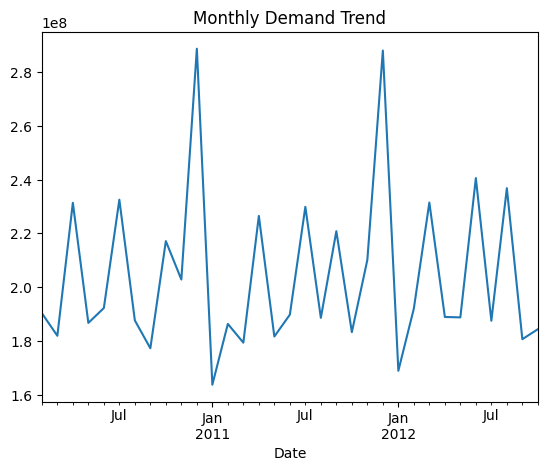

In [7]:
monthly_sales.plot()
plt.title("Monthly Demand Trend")
plt.show()

In [8]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# model
model = SARIMAX(monthly_sales, order=(1,1,1), seasonal_order=(1,1,1,12))

# fit
results = model.fit()

# forecast next 12 months
forecast = results.forecast(steps=12)

print(forecast)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


2012-11-30    1.917964e+08
2012-12-31    2.524799e+08
2013-01-31    1.693481e+08
2013-02-28    2.071119e+08
2013-03-31    2.287661e+08
2013-04-30    2.135602e+08
2013-05-31    2.038506e+08
2013-06-30    2.366191e+08
2013-07-31    2.131887e+08
2013-08-31    2.335879e+08
2013-09-30    2.024839e+08
2013-10-31    2.038711e+08
Freq: ME, Name: predicted_mean, dtype: float64


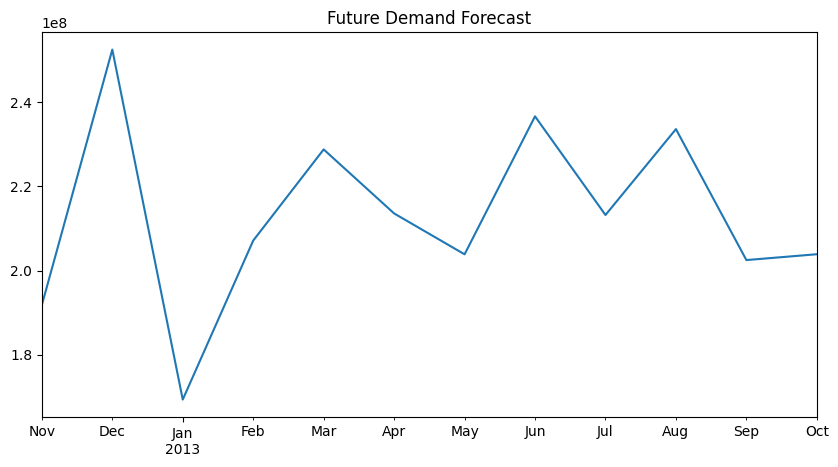

In [9]:
forecast.plot(figsize=(10,5))
plt.title("Future Demand Forecast")
plt.show()